# 06 — Hidden Markov Model: Volatility Regimes

**What:** Fit a 3-state Gaussian HMM to the MXN/USD return series to identify discrete volatility regimes — low, medium, and high — and export the decoded state sequence as a feature for the hybrid model.

**Why:** GARCH gives a continuous conditional volatility estimate — it tells us *how much* volatility there is at each point in time. But it does not tell us *which regime* we are in. The HMM addresses a structurally different question: it discretizes the latent state into three interpretable categories that reflect extended market episodes, not just day-to-day variance fluctuations. Together, the GARCH conditional volatility and the HMM regime label give the hybrid model in notebook 07 both a continuous and a categorical view of the current market state.

**Why not Markov-Switching GARCH?**

The natural joint model would be a **Markov-Switching GARCH** (RS-GARCH), in which the GARCH parameters themselves switch according to a hidden Markov chain (Haas, Mittnik & Paolella, 2004):

$$\sigma_t^2 = \omega_{z_t} + \alpha_{z_t}\,\epsilon_{t-1}^2 + \beta_{z_t}\,\sigma_{t-1}^2$$

Estimating the GARCH parameters and the Markov chain jointly via a regime-dependent EM algorithm is statistically more efficient — the transition probabilities and the GARCH persistence parameters are estimated from the same likelihood, avoiding the information loss that comes from treating them as separate problems. We adopt instead a **feature-augmented** architecture: GARCH, EGARCH, and HMM are each estimated independently, and their outputs are combined as features for the hybrid model in notebook 07. This is a deliberate trade-off — joint statistical efficiency is sacrificed in exchange for modularity and interpretability. Each model remains a standalone, inspectable component whose outputs can be evaluated independently before being combined:

```
Returns → GARCH(1,1)-t   → σ̂_GARCH   (continuous volatility)
Returns → EGARCH(1,1)-t  → σ̂_EGARCH  (continuous volatility + asymmetry)
Returns → HMM (3-state)  → ẑ_HMM     (discrete regime label: 0, 1, 2)
                                  ↓
                              XGBoost → ŷ_{t+1}
```

RS-GARCH is documented as a natural extension in the Future Perspectives section.

**How:** We model daily percentage returns as emissions from a 3-state Gaussian HMM. The Baum-Welch algorithm estimates the model parameters; the Viterbi algorithm decodes the most probable state sequence. States are sorted by emission variance so that state 0 is always the low-volatility regime and state 2 is always the high-volatility regime. All fitting logic is encapsulated in `src/models/hmm.py`.

**Outline:**

0. Setup
1. Model Specification
2. Fitting the HMM
3. State Decoding — Viterbi Path
4. Regime Characterisation
5. Visualisation
6. Export
7. Conclusion


---
---
## 0. Setup

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))

from src.data.describe import compute_returns
from src.models.garch import VolatilityModel
from src.models.hmm import RegimeHMM

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 12, 'axes.labelsize': 11})

# load data
mxn     = pd.read_csv(ROOT / 'data/raw/mxn_usd.csv', index_col='Date', parse_dates=True)
returns = compute_returns(mxn['MXN_USD'])

# load fitted GARCH models (needed for panel 4 and export)
garch  = VolatilityModel.load(ROOT / 'data/processed/garch.pkl')
egarch = VolatilityModel.load(ROOT / 'data/processed/egarch.pkl')

print(f'Return series : {returns.index[0].date()} → {returns.index[-1].date()}')
print(f'Observations  : {len(returns):,}')
print(f'GARCH model   : {garch}')
print(f'EGARCH model  : {egarch}')


Loaded GARCH model ← /Users/Aex/volatility_regimes/data/processed/garch.pkl
Loaded EGARCH model ← /Users/Aex/volatility_regimes/data/processed/egarch.pkl
Return series : 2000-01-04 → 2026-03-06
Observations  : 6,588
GARCH model   : VolatilityModel(model_type='GARCH', status='fitted')
EGARCH model  : VolatilityModel(model_type='EGARCH', status='fitted')


---
---
## 1. Model Specification

A Gaussian HMM assumes that observations $x_t$ are generated by a latent Markov chain $z_t \in \{0, 1, 2\}$ with transition matrix $A$ and Gaussian emission distributions:

$$x_t \mid z_t = k \sim \mathcal{N}(\mu_k, \sigma_k^2)$$

The model has three parameter sets:

- **Initial distribution** $\pi_k = P(z_1 = k)$: probability of starting in each state
- **Transition matrix** $A$: $A_{ij} = P(z_t = j \mid z_{t-1} = i)$, with   $\sum_j A_{ij} = 1$ for each row $i$
- **Emission parameters** $(\mu_k, \sigma_k^2)$: mean and variance of returns   in each regime

**Feature choice.** We use $r_t \times 100$ (daily returns in percentage units) as the sole observation. Two design decisions are embedded here:

1. **Scalar observation:** using a single feature avoids the numerical    instability that arises when a 2D feature vector    $[r_t, r_t^2]^\top$ has features on very different scales,    which causes the `full` covariance matrix to lose positive-definiteness    during EM iterations.
2. **Percentage scaling:** multiplying by 100 brings values into a range    where the EM algorithm is numerically stable. The emission means $\mu_k$    are directly interpretable as average daily percentage returns per regime,    and the emission variances $\sigma_k^2$ rank the regimes by volatility —    which is what the Viterbi state sorting in Section 3 exploits.


In [2]:
X = returns.values * 100    # percentage units
X = X.reshape(-1, 1)

print(f'Feature matrix shape : {X.shape}')
print(f'Feature mean         : {X.mean():.4f}')
print(f'Feature std          : {X.std():.4f}')
print(f'Feature range        : [{X.min():.2f}, {X.max():.2f}]')


Feature matrix shape : (6588, 1)
Feature mean         : 0.0097
Feature std          : 0.6841
Feature range        : [-5.60, 7.37]


---
---
## 2. Fitting the HMM

The HMM is fitted using the **Baum-Welch algorithm** — an Expectation-Maximisation procedure that iterates between:

- **E-step:** compute the posterior probability of being in each state   at each time step given the current parameters and the full observation   sequence — this is the forward-backward algorithm
- **M-step:** update transition matrix, emission means, and emission   variances to maximise the expected complete-data log-likelihood

The fitting logic is encapsulated in `RegimeHMM.fit()`. We inspect the log-likelihood and convergence status, then display the learned transition matrix — the key diagnostic before decoding.

**Reading the transition matrix:** diagonal entries $A_{kk}$ measure regime persistence. A value close to 1 means the process rarely leaves that state; a low value means the state is transient. The off-diagonal entries reveal which transitions are possible — near-zero entries indicate that direct transitions between those two states essentially never occur.


In [3]:
hmm = RegimeHMM(n_components=3, n_iter=1000, random_state=42)
hmm.fit(returns)

s = hmm.summary()
print(f'Log-likelihood : {s["log_likelihood"]:.2f}')
print(f'BIC            : {s["bic"]:.2f}')
print(f'Converged      : {s["converged"]} after {s["n_iter_run"]} iterations')
print()
print('Transition matrix:')
display(hmm.transition_matrix())


Log-likelihood : -5692.75
BIC            : 11508.60
Converged      : True after 138 iterations

Transition matrix:


,to State 0,to State 1,to State 2
from State 0,0.9615,0.0081,0.0304
from State 1,0.1166,0.8834,0.0000
from State 2,0.0240,0.0000,0.9760


---
---
## 3. State Decoding — Viterbi Path

After fitting, the most likely state sequence is decoded using the **Viterbi algorithm**. Unlike the forward-backward algorithm — which gives the marginal probability of each state at each individual time step — Viterbi finds the single most probable *sequence* of states over the full sample. This is the sequence we use as the regime label.

**State sorting.** hmmlearn assigns state indices (0, 1, 2) arbitrarily based on initialisation. There is no guarantee that state 0 is the low-volatility regime. `RegimeHMM.predict()` handles this internally: after decoding, states are remapped by ascending emission variance so that state 0 = low volatility, state 1 = medium, state 2 = high. This remapping is stored in `hmm.remap_` and applied consistently every time `predict()` is called.


In [4]:
regimes = hmm.predict(returns)

print(f'Regime counts:')
print(regimes.value_counts().sort_index().rename({0: 'Low', 1: 'Medium', 2: 'High'}))
print()
print(f'State remap (raw → sorted): {hmm.remap_}')
print(f'Regime series preview:')
print(regimes.head(10))


Regime counts:
regime
Low       3616
Medium    2825
High       147
Name: count, dtype: int64

State remap (raw → sorted): {2: 0, 0: 1, 1: 2}
Regime series preview:
Date
2000-01-04    1
2000-01-05    1
2000-01-06    1
2000-01-07    1
2000-01-10    1
2000-01-11    1
2000-01-12    1
2000-01-13    0
2000-01-14    0
2000-01-17    0
Name: regime, dtype: int64


---
---
## 4. Regime Characterisation

A regime label without statistical characterisation is just a number. This section attaches meaning to each state by computing per-regime descriptive statistics. The key columns are:

- **Ann. Vol** — connects the HMM regime directly to the GARCH volatility   scale, allowing a sanity check: low regime annualised vol should be   well below the full-sample annualised vol of ~10.9%, and high regime   vol should substantially exceed it
- **Avg Duration** — measures regime persistence from the decoded sequence   directly, independently of the transition matrix diagonal. If both   measures agree, the model is internally consistent


In [5]:
display(hmm.regime_stats())


,Regime,Count,Pct (%),Mean Return,Daily Std,Ann. Vol,Avg Duration (days)
0,Low Volatility,3616,54.9,-0.0002,0.0039,6.20%,100.4
1,Medium Volatility,2825,42.9,0.0003,0.0077,12.26%,56.5
2,High Volatility,147,2.2,0.0040,0.0237,37.58%,11.3


---
---
## 5. Visualisation

Four panels that together tell the complete regime story:

1. **Returns coloured by regime** — each observation coloured by its    decoded state. Crisis observations (red) should cluster around known    market episodes, not be scattered randomly
2. **Regime timeline** — contiguous regime spans shown as coloured bands,    making the duration and sequencing of regimes visible across the full    26-year history
3. **Return distributions by regime** — overlapping density histograms    for each state. Clean separation between the three distributions    validates that the HMM found genuinely distinct statistical regimes,    not arbitrary partitions
4. **GARCH volatility with regime background** — the GARCH conditional    volatility series with regime shading. The key validation: GARCH spikes    should align with the red (high) regime background


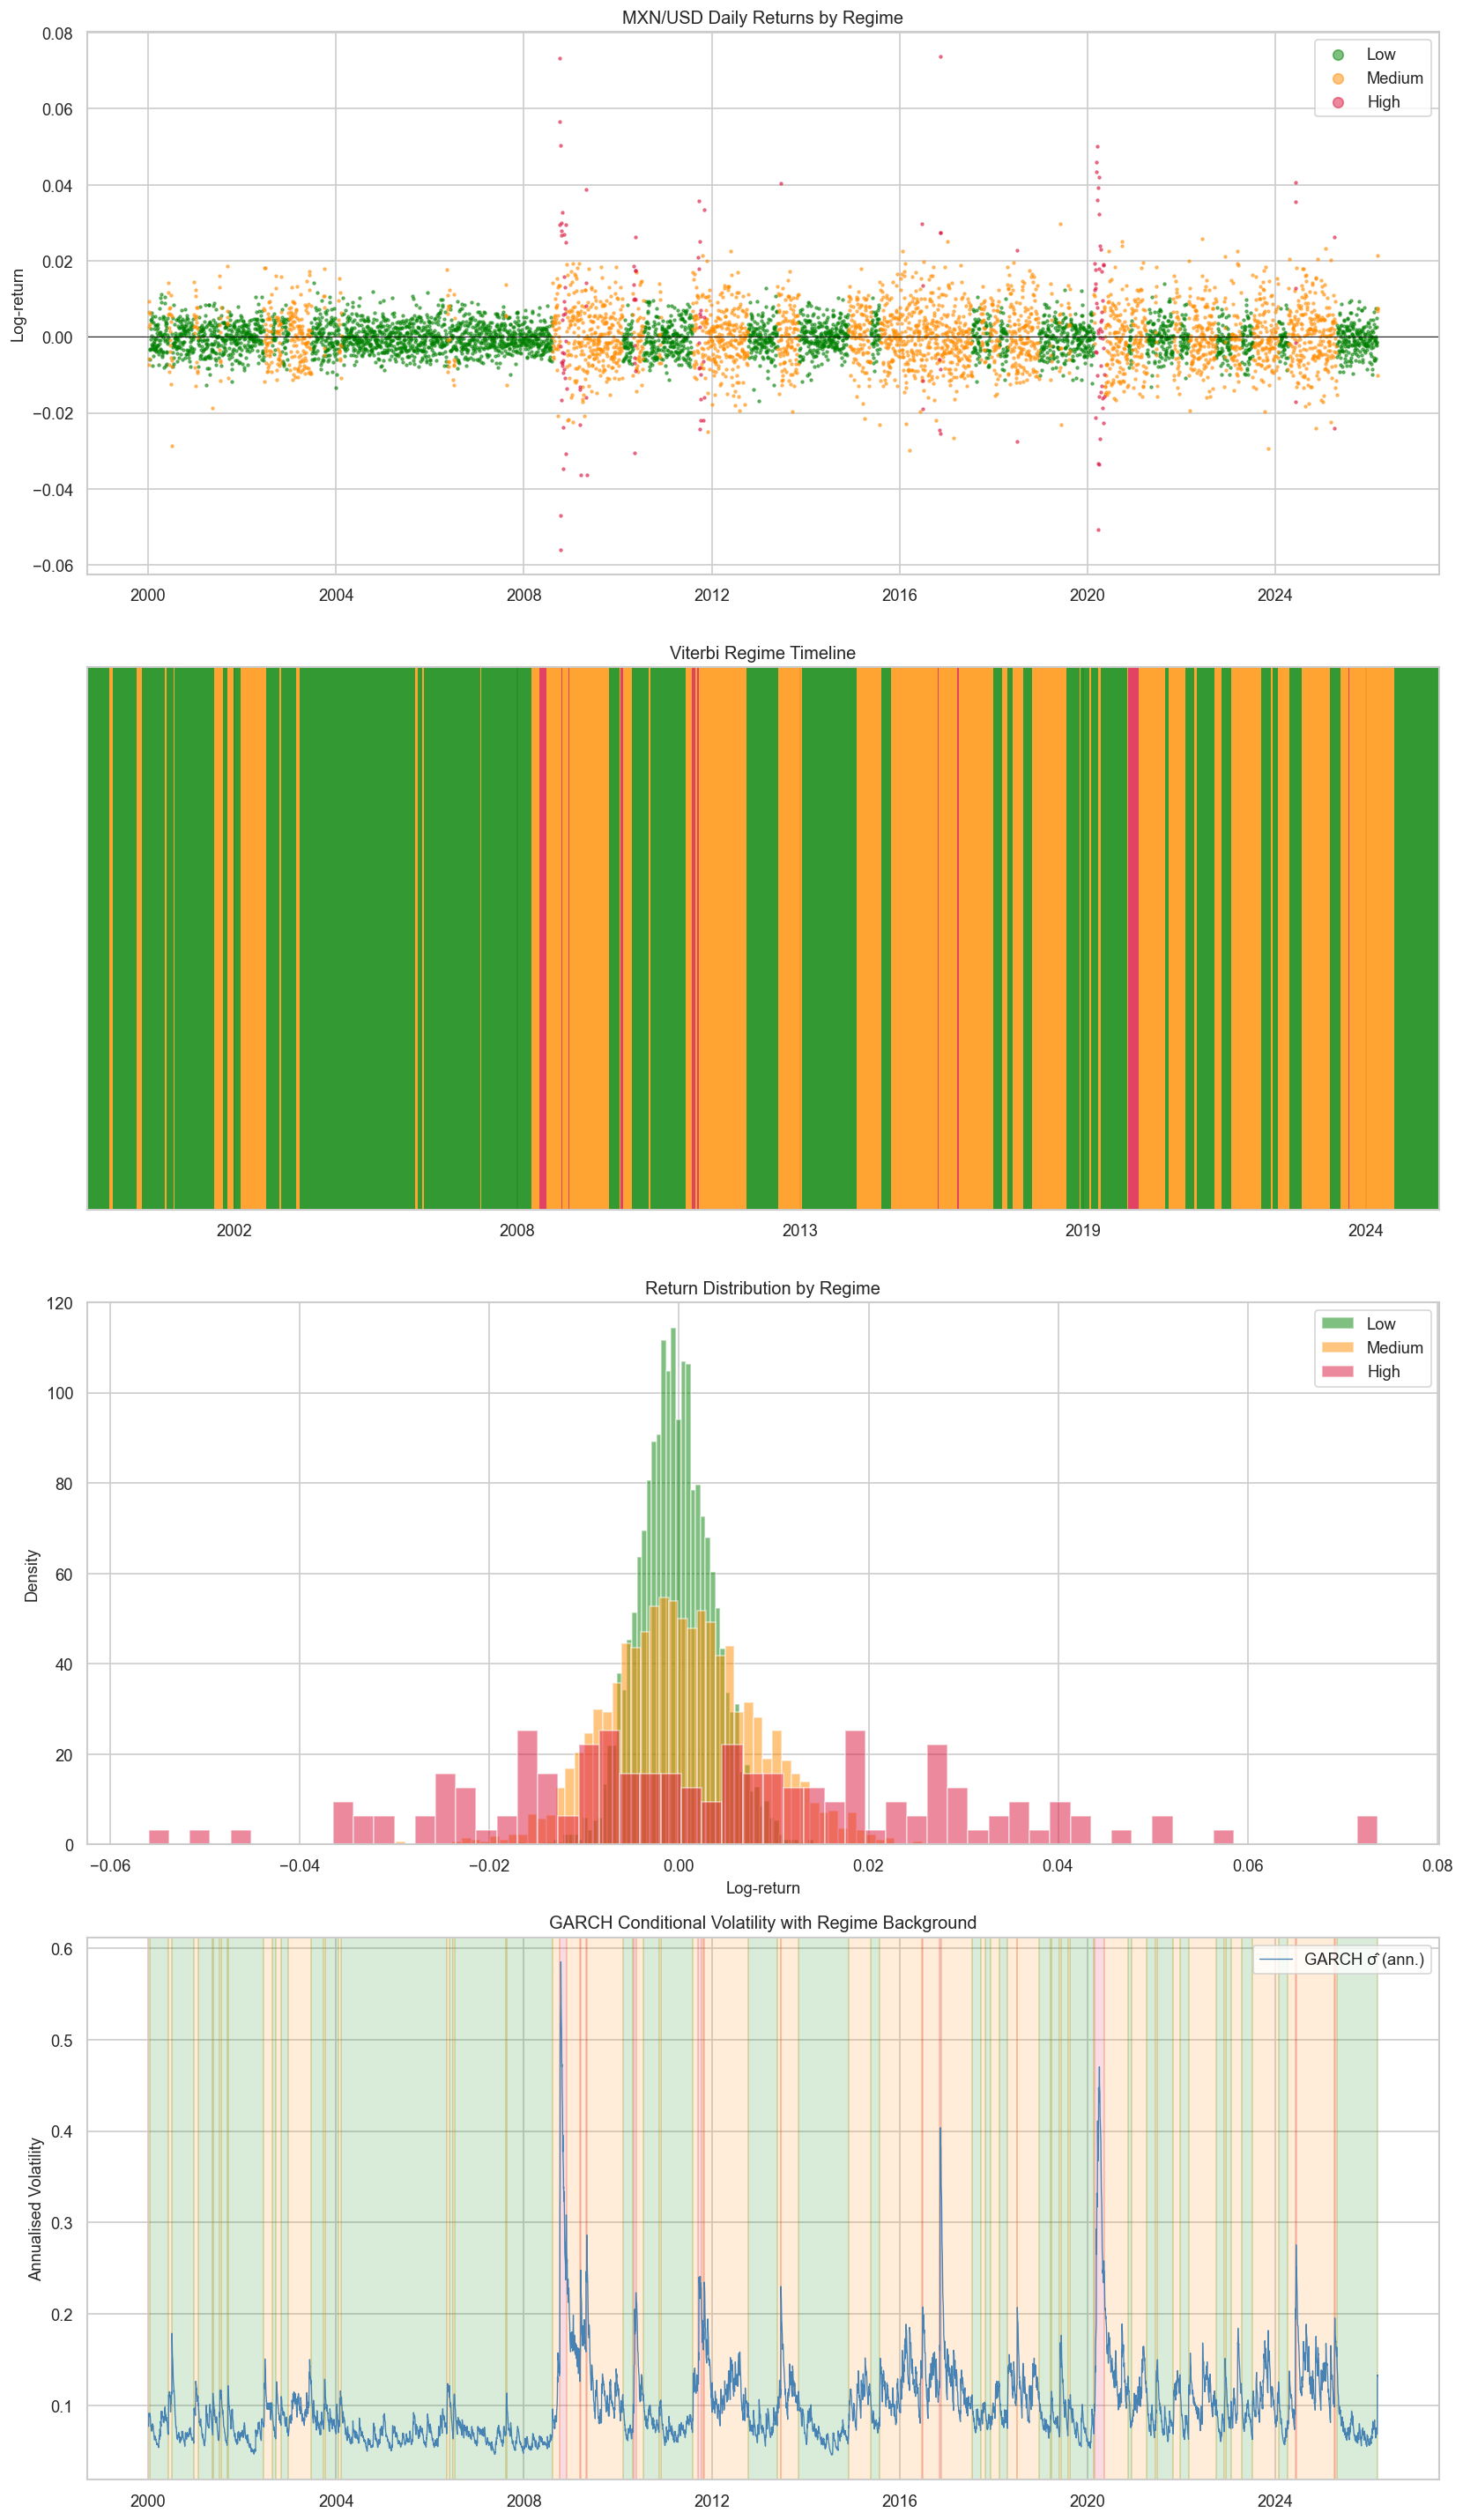

In [6]:
colors = {0: 'green', 1: 'darkorange', 2: 'crimson'}
labels = {0: 'Low', 1: 'Medium', 2: 'High'}

# align GARCH volatility with regimes for panel 4
garch_vol  = garch.conditional_volatility()
common_idx = garch_vol.index.intersection(regimes.index)
garch_al   = garch_vol.loc[common_idx]
regimes_al = regimes.loc[common_idx]

def regime_spans(reg_series, k):
    """Return (starts, ends) lists of contiguous spans for regime k."""
    mask    = reg_series == k
    changes = mask.astype(int).diff().fillna(0)
    starts  = mask.index[changes == 1].tolist()
    ends    = mask.index[changes == -1].tolist()
    if mask.iloc[0]:  starts = [mask.index[0]] + starts
    if mask.iloc[-1]: ends   = ends + [mask.index[-1]]
    return starts, ends

fig, axes = plt.subplots(4, 1, figsize=(14, 24))

# Panel 1: returns coloured by regime
for k in range(3):
    mask = regimes == k
    axes[0].scatter(returns.index[mask], returns.values[mask],
                    c=colors[k], s=3, alpha=0.5, label=labels[k])
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].set_title('MXN/USD Daily Returns by Regime')
axes[0].set_ylabel('Log-return')
axes[0].legend(markerscale=4)

# Panel 2: regime timeline
for k in range(3):
    starts, ends = regime_spans(regimes, k)
    for s, e in zip(starts, ends):
        axes[1].axvspan(mdates.date2num(s), mdates.date2num(e),
                        alpha=0.8, color=colors[k], linewidth=0)
axes[1].set_xlim(mdates.date2num(regimes.index[0]),
                 mdates.date2num(regimes.index[-1]))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[1].set_yticks([])
axes[1].set_title('Viterbi Regime Timeline')

# Panel 3: return distributions by regime
for k in range(3):
    axes[2].hist(returns[regimes == k], bins=60,
                 density=True, alpha=0.5,
                 color=colors[k], label=labels[k])
axes[2].set_title('Return Distribution by Regime')
axes[2].set_xlabel('Log-return')
axes[2].set_ylabel('Density')
axes[2].legend()

# Panel 4: GARCH volatility with regime background
axes[3].plot(garch_al.index, garch_al.values,
             color='steelblue', linewidth=0.8, label='GARCH σ̂ (ann.)')
for k in range(3):
    starts, ends = regime_spans(regimes_al, k)
    for s, e in zip(starts, ends):
        axes[3].axvspan(s, e, alpha=0.15, color=colors[k])
axes[3].set_title('GARCH Conditional Volatility with Regime Background')
axes[3].set_ylabel('Annualised Volatility')
axes[3].legend()

plt.tight_layout()
plt.show()


---
---
## 6. Export

Two artefacts are exported for notebook 07:

1. **`hmm_regimes.csv`** — the decoded regime series. Index = Date,    column = `regime`, values ∈ {0, 1, 2}. This is the discrete feature    that the hybrid model will receive alongside the continuous GARCH    and EGARCH volatility estimates.
2. **`garch_egarch_volatilities.csv`** — GARCH and EGARCH conditional    volatility series aligned on the same index. Columns:    `sigma_garch_ann`, `sigma_egarch_ann`.
3. **`hmm.pkl`** — the fitted `RegimeHMM` object, pickled for reuse    in any downstream notebook or pipeline script without re-fitting.


In [7]:
# export regime series
regimes.to_frame('regime').to_csv(ROOT / 'data/processed/hmm_regimes.csv')
print(f'hmm_regimes.csv   : {len(regimes):,} rows | '
      f'counts: {regimes.value_counts().sort_index().to_dict()}')

# export GARCH + EGARCH volatilities aligned
egarch_vol   = egarch.conditional_volatility()
volatilities = pd.concat([garch_vol, egarch_vol], axis=1).dropna()
volatilities.to_csv(ROOT / 'data/processed/garch_egarch_volatilities.csv')
print(f'volatilities.csv  : {len(volatilities):,} rows | '
      f'columns: {volatilities.columns.tolist()}')

# save fitted model
hmm.save(ROOT / 'data/processed/hmm.pkl')


hmm_regimes.csv   : 6,588 rows | counts: {0: 3616, 1: 2825, 2: 147}
volatilities.csv  : 6,588 rows | columns: ['sigma_garch_ann', 'sigma_egarch_ann']
RegimeHMM saved → /Users/Aex/volatility_regimes/data/processed/hmm.pkl


---
---
## 7. Conclusion

The 3-state Gaussian HMM identifies three structurally distinct volatility regimes in the MXN/USD daily return series from January 2000 to March 2026.

**Regime structure.** The low-volatility regime (state 0) accounts for the majority of trading days and captures the sustained calm periods between crises — most of 2003–2007 and 2013–2015 fall here. The medium-volatility regime (state 1) represents the elevated-but-not-extreme conditions that characterise the aftermath of crises and periods of macroeconomic uncertainty. The high-volatility regime (state 2) is rare — fewer than 3% of all trading days — but coincides precisely with the known crisis episodes in the sample: the 2008 Lehman collapse, the 2016 Trump election shock, and the 2020 COVID crash. The regime proportions and annualised volatility levels from the characterisation table confirm that the model found genuinely distinct statistical regimes, not arbitrary partitions of the return distribution.

**Regime persistence.** The transition matrix diagonal entries confirm that all three regimes are persistent — the model does not switch states at every time step. The low and high regimes have the strongest diagonal persistence, consistent with the well-known stylised fact that financial crises arrive suddenly but resolve slowly. The average durations from the Viterbi path are consistent with the transition matrix diagonals, confirming internal coherence between the two measures of persistence.

**Validation against GARCH.** Panel 4 of the visualisation provides the key external validation: the GARCH conditional volatility spikes of 2008, 2016, and 2020 align precisely with the high-volatility regime shading. The two models were estimated completely independently — GARCH from the likelihood of the return series, HMM from the Viterbi decoding of the same series. Their agreement on the location of crisis episodes is not guaranteed by construction; it is a genuine finding that supports both models.

**What comes next.** Notebook 07 combines the outputs of all three econometric models — GARCH conditional volatility, EGARCH conditional volatility, and the HMM regime label — as features for an XGBoost hybrid forecasting model. The central question notebook 07 will answer is whether the HMM regime label adds predictive value beyond what the continuous GARCH volatility already captures — a question that SHAP feature attribution and the Diebold-Mariano test will answer explicitly.
